# Acrobot (2-DoF manipulator) — reach-avoid MPC with certificate-based terminal set


In [1]:
# ── Load computed certificate + controller ────────────────────────────────────
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca
from acrobot_inverse_kinematics import inverse_kinematics
from functional import BetterColor

from sop_bounded_control_acrobot_result_20260317_222858 import (
    u_opt,
    certificate_opt,
    k1_opt,
)

u_opt = sp.Matrix(u_opt)
k1_opt = sp.Matrix(k1_opt)

# ── Symbolic variables ────────────────────────────────────────────────────────
x1, x2, x3, x4 = sp.symbols("x1 x2 x3 x4")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, x3, x4]  # [q1, q2, dq1, dq2]

# ── Physical parameters ───────────────────────────────────────────────────────
m1, m2 = 1.0, 1.0
l1, l2 = 4.0, 4.0
lc1, lc2 = 2.0, 2.0
I1, I2 = 0.02, 0.02
g_grav = 9.81

TARGET_POS = np.array([5.8, 1.9])  # target ellipse centre in y-space


# ── Set functions ─────────────────────────────────────────────────────────────
def psi_y_np(y1v, y2v):
    return -((4 * (y1v - 2) - 2 * y2v**3) ** 2) + 0.8 * y2v**3 + 10


def phi_y_np(y1v, y2v):
    return ((y1v - 2 - 3.5) ** 2 / 1.2**2) + ((y2v - 1.8) ** 2 / 0.4**2) - 2


def h_np(x_):
    q1, q2 = x_[0], x_[1]
    return np.array(
        [l1 * np.cos(q1) + l2 * np.cos(q1 + q2), l1 * np.sin(q1) + l2 * np.sin(q1 + q2)]
    )


def psi_x_np(x_):
    y = h_np(x_)
    return psi_y_np(y[0], y[1])


def phi_x_np(x_):
    y = h_np(x_)
    return phi_y_np(y[0], y[1])


def psi_x_vec(x_):
    q1, q2 = x_[0], x_[1]
    y1v = l1 * np.cos(q1) + l2 * np.cos(q1 + q2)
    y2v = l1 * np.sin(q1) + l2 * np.sin(q1 + q2)
    return psi_y_np(y1v, y2v)


def phi_x_vec(x_):
    q1, q2 = x_[0], x_[1]
    y1v = l1 * np.cos(q1) + l2 * np.cos(q1 + q2)
    y2v = l1 * np.sin(q1) + l2 * np.sin(q1 + q2)
    return phi_y_np(y1v, y2v)


psi_y_func = sp.lambdify(
    [y1, y2], -((4 * (y1 - 2) - 2 * y2**3) ** 2) + 0.8 * y2**3 + 10, "numpy"
)
phi_y_func = sp.lambdify(
    [y1, y2], ((y1 - 2 - 3.5) ** 2 / 1.2**2) + ((y2 - 1.8) ** 2 / 0.4**2) - 2, "numpy"
)
cert_func = sp.lambdify(state_vars, certificate_opt, "numpy")
k1_func = sp.lambdify([y1, y2], list(k1_opt), "numpy")


# ── Numpy acrobot RHS (for DOP853 integration) ────────────────────────────────
def acrobot_rhs_np(t, x_, u_):
    q1, q2, dq1, dq2 = x_
    M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * np.cos(q2))
    M12 = m2 * (lc2**2 + l1 * lc2 * np.cos(q2)) + I2
    M_mat = np.array([[M11, M12], [M12, m2 * lc2**2 + I2]])
    C_mat = np.array(
        [
            [
                -m2 * l1 * lc2 * np.sin(q2) * dq2,
                -m2 * l1 * lc2 * np.sin(q2) * (dq1 + dq2),
            ],
            [m2 * l1 * lc2 * np.sin(q2) * dq1, 0.0],
        ]
    )
    G_vec = np.array(
        [
            (m1 * g_grav * lc1 + m2 * g_grav * l1) * np.cos(q1)
            + m2 * g_grav * lc2 * np.cos(q1 + q2),
            m2 * g_grav * lc2 * np.cos(q1 + q2),
        ]
    )
    qdot = np.array([dq1, dq2])
    qddot = np.linalg.solve(M_mat, -C_mat @ qdot - G_vec + np.asarray(u_))
    return [dq1, dq2, qddot[0], qddot[1]]


print("Certificate symbols:", certificate_opt.free_symbols)
print("k1_opt    symbols  :", k1_opt[0].free_symbols)

Certificate symbols: {x2, x3, x1, x4}
k1_opt    symbols  : {y2, y1}


In [2]:
# ── SymPy → CasADi converter (handles polynomials and trig) ──────────────────
def sympy2casadi(expr, sym_map):
    """Recursively convert a SymPy expression to CasADi SX."""
    if isinstance(
        expr,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
            sp.core.numbers.Pi,
            sp.core.numbers.Exp1,
        ),
    ):
        return float(expr)
    elif isinstance(expr, sp.Symbol):
        return sym_map[expr]
    elif isinstance(expr, sp.Add):
        return sum(sympy2casadi(a, sym_map) for a in expr.args)
    elif isinstance(expr, sp.Mul):
        result = 1.0
        for a in expr.args:
            result = result * sympy2casadi(a, sym_map)
        return result
    elif isinstance(expr, sp.Pow):
        return sympy2casadi(expr.args[0], sym_map) ** sympy2casadi(
            expr.args[1], sym_map
        )
    elif isinstance(expr, sp.sin):
        return ca.sin(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.cos):
        return ca.cos(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.Number):
        return float(expr)
    else:
        raise ValueError(f"Unsupported sympy type: {type(expr)}  --  {expr}")


# ── CasADi SX symbols ────────────────────────────────────────────────────────
ca_x1 = ca.SX.sym("x1")
ca_x2 = ca.SX.sym("x2")
ca_x3 = ca.SX.sym("x3")
ca_x4 = ca.SX.sym("x4")
sym_map = {x1: ca_x1, x2: ca_x2, x3: ca_x3, x4: ca_x4}

cert_ca_expr = sympy2casadi(certificate_opt, sym_map)
cert_ca_f = ca.Function("cert", [ca_x1, ca_x2, ca_x3, ca_x4], [cert_ca_expr])


def cert_ca_vec(xv):
    return cert_ca_f(xv[0], xv[1], xv[2], xv[3])


def safe_ca_vec(xv):
    """psi(h(x)) >= 0 — safe set directly in CasADi."""
    y1v = l1 * ca.cos(xv[0]) + l2 * ca.cos(xv[0] + xv[1])
    y2v = l1 * ca.sin(xv[0]) + l2 * ca.sin(xv[0] + xv[1])
    return -((4 * (y1v - 2) - 2 * y2v**3) ** 2) + 0.8 * y2v**3 + 10


def h_ca(xv):
    return ca.vertcat(
        l1 * ca.cos(xv[0]) + l2 * ca.cos(xv[0] + xv[1]),
        l1 * ca.sin(xv[0]) + l2 * ca.sin(xv[0] + xv[1]),
    )


# ── Sanity check ──────────────────────────────────────────────────────────────
test_x = np.array([-1.0, 2.0, 0.1, -0.1])
v_sp = float(certificate_opt.subs(dict(zip(state_vars, test_x))))
v_ca = float(cert_ca_f(*test_x))
print(f"Certificate:  sympy={v_sp:.6f}  casadi={v_ca:.6f}  diff={abs(v_sp-v_ca):.2e}")
assert abs(v_sp - v_ca) < 1e-3, "Conversion mismatch!"
print("Conversion verified OK.")

# ── CasADi acrobot dynamics + RK4 ────────────────────────────────────────────
dt_mpc = 0.01  # MPC discretisation step [s]
N_hor = 20  # prediction horizon (steps)
u_max = 500.0  # torque bound [N·m]

xc = ca.MX.sym("x", 4)
uc = ca.MX.sym("u", 2)


def acrobot_ca(x, u):
    q1, q2, dq1, dq2 = x[0], x[1], x[2], x[3]
    M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * ca.cos(q2))
    M12 = m2 * (lc2**2 + l1 * lc2 * ca.cos(q2)) + I2
    M_ca = ca.vertcat(ca.horzcat(M11, M12), ca.horzcat(M12, m2 * lc2**2 + I2))
    C_ca = ca.vertcat(
        ca.horzcat(
            -m2 * l1 * lc2 * ca.sin(q2) * dq2, -m2 * l1 * lc2 * ca.sin(q2) * (dq1 + dq2)
        ),
        ca.horzcat(m2 * l1 * lc2 * ca.sin(q2) * dq1, ca.DM(0.0)),
    )
    G_ca = ca.vertcat(
        (m1 * g_grav * lc1 + m2 * g_grav * l1) * ca.cos(q1)
        + m2 * g_grav * lc2 * ca.cos(q1 + q2),
        m2 * g_grav * lc2 * ca.cos(q1 + q2),
    )
    qdot = ca.vertcat(dq1, dq2)
    qddot = ca.solve(M_ca, -C_ca @ qdot - G_ca + u)
    return ca.vertcat(dq1, dq2, qddot[0], qddot[1])


rhs_ca = ca.Function("f", [xc, uc], [acrobot_ca(xc, uc)])


def rk4_ca(x, u):
    k1 = rhs_ca(x, u)
    k2 = rhs_ca(x + dt_mpc / 2 * k1, u)
    k3 = rhs_ca(x + dt_mpc / 2 * k2, u)
    k4 = rhs_ca(x + dt_mpc * k3, u)
    return x + (dt_mpc / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


# ── Numpy RK4 for fast warm-start rollout (no CasADi overhead) ───────────────
def rk4_np(x, u):
    k1 = np.array(acrobot_rhs_np(0, x, u))
    k2 = np.array(acrobot_rhs_np(0, x + dt_mpc / 2 * k1, u))
    k3 = np.array(acrobot_rhs_np(0, x + dt_mpc / 2 * k2, u))
    k4 = np.array(acrobot_rhs_np(0, x + dt_mpc * k3, u))
    return x + (dt_mpc / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


_IPOPT_OPTS = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 500,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}


# ── solve_mpc: fresh Opti per call  (used for parallel feasibility check) ────
# The Opti object cannot be shared across processes, so feasibility checking
# (joblib multiprocessing) must create a fresh NLP each call.
def solve_mpc(x0_val, U_warm=None):
    opti = ca.Opti()
    X = opti.variable(4, N_hor + 1)
    U = opti.variable(2, N_hor)
    x0_np = np.asarray(x0_val, dtype=float).flatten()
    opti.subject_to(X[:, 0] == x0_np)
    for k in range(N_hor):
        opti.subject_to(X[:, k + 1] == rk4_ca(X[:, k], U[:, k]))
        opti.subject_to(safe_ca_vec(X[:, k]) >= 0)
    opti.subject_to(safe_ca_vec(X[:, N_hor]) >= 0)
    opti.subject_to(cert_ca_vec(X[:, N_hor]) >= 0)
    opti.subject_to(opti.bounded(-u_max, U[0, :], u_max))
    opti.subject_to(opti.bounded(-u_max, U[1, :], u_max))
    tgt = ca.DM(TARGET_POS)
    Q_y = ca.DM([[5.0, 0], [0, 5.0]])
    Qf_y = ca.DM([[80.0, 0], [0, 80.0]])
    R_u = ca.DM([[0.001, 0], [0, 0.001]])
    cost = 0
    for k in range(N_hor):
        dy = h_ca(X[:, k]) - tgt
        cost += dy.T @ Q_y @ dy + U[:, k].T @ R_u @ U[:, k]
    cost += (h_ca(X[:, N_hor]) - tgt).T @ Qf_y @ (h_ca(X[:, N_hor]) - tgt)
    opti.minimize(cost)
    if U_warm is not None:
        U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
        X_ws = np.zeros((4, N_hor + 1))
        X_ws[:, 0] = x0_np
        for k in range(N_hor):
            X_ws[:, k + 1] = np.asarray(rk4_ca(X_ws[:, k], U_ws[:, k])).flatten()
        opti.set_initial(X, X_ws)
        opti.set_initial(U, U_ws)
    else:
        x_tgt_full = np.array([np.arctan2(TARGET_POS[1], TARGET_POS[0]), 0.0, 0.0, 0.0])
        X_ws = np.array(
            [
                (1 - k / N_hor) * x0_np + (k / N_hor) * x_tgt_full
                for k in range(N_hor + 1)
            ]
        ).T
        opti.set_initial(X, X_ws)
        opti.set_initial(U, 0)
    opti.solver("ipopt", _IPOPT_OPTS)
    try:
        sol = opti.solve()
        return True, np.asarray(sol.value(U))
    except Exception:
        return False, None


# ── Pre-compile parametric NLP once  (used for sequential simulation) ─────────
#
#  Key idea: build the NLP structure once with x0 as a CasADi *parameter*.
#  In the simulation loop we only call set_value(x0) + set_initial(warm_start)
#  + solve() — the expensive symbolic graph compilation is skipped entirely.
#
_opti_mpc = ca.Opti()
_X_mpc = _opti_mpc.variable(4, N_hor + 1)
_U_mpc = _opti_mpc.variable(2, N_hor)
_x0_mpc = _opti_mpc.parameter(4)  # ← parametric initial state

_opti_mpc.subject_to(_X_mpc[:, 0] == _x0_mpc)
for _k in range(N_hor):
    _opti_mpc.subject_to(_X_mpc[:, _k + 1] == rk4_ca(_X_mpc[:, _k], _U_mpc[:, _k]))
    _opti_mpc.subject_to(safe_ca_vec(_X_mpc[:, _k]) >= 0)
_opti_mpc.subject_to(safe_ca_vec(_X_mpc[:, N_hor]) >= 0)
_opti_mpc.subject_to(cert_ca_vec(_X_mpc[:, N_hor]) >= 0)
_opti_mpc.subject_to(_opti_mpc.bounded(-u_max, _U_mpc[0, :], u_max))
_opti_mpc.subject_to(_opti_mpc.bounded(-u_max, _U_mpc[1, :], u_max))

_tgt = ca.DM(TARGET_POS)
_Q_y = ca.DM([[5.0, 0], [0, 5.0]])
_Qf_y = ca.DM([[80.0, 0], [0, 80.0]])
_R_u = ca.DM([[0.001, 0], [0, 0.001]])
_cost = 0
for _k in range(N_hor):
    _dy = h_ca(_X_mpc[:, _k]) - _tgt
    _cost += _dy.T @ _Q_y @ _dy + _U_mpc[:, _k].T @ _R_u @ _U_mpc[:, _k]
_dy_N = h_ca(_X_mpc[:, N_hor]) - _tgt
_cost += _dy_N.T @ _Qf_y @ _dy_N
_opti_mpc.minimize(_cost)
_opti_mpc.solver("ipopt", _IPOPT_OPTS)
print("Parametric MPC compiled (used for simulation loop).")


def solve_mpc_fast(x0_val, U_warm=None):
    """
    Reuses the pre-compiled parametric NLP.

    Speedup vs solve_mpc
    --------------------
    * No Opti / constraint graph construction       (saves ~70-90 % of overhead)
    * Warm-start rollout uses rk4_np (pure numpy)   (avoids 20 CasADi function calls)
    * Only set_value + set_initial + solve() called per step
    """
    x0_np = np.asarray(x0_val, dtype=float).flatten()
    _opti_mpc.set_value(_x0_mpc, x0_np)

    if U_warm is not None:
        U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
        X_ws = np.zeros((4, N_hor + 1))
        X_ws[:, 0] = x0_np
        for k in range(N_hor):
            X_ws[:, k + 1] = rk4_np(
                X_ws[:, k], U_ws[:, k]
            )  # ← numpy, no CasADi overhead
        _opti_mpc.set_initial(_X_mpc, X_ws)
        _opti_mpc.set_initial(_U_mpc, U_ws)
    else:
        x_tgt_full = np.array([np.arctan2(TARGET_POS[1], TARGET_POS[0]), 0.0, 0.0, 0.0])
        X_ws = np.array(
            [
                (1 - k / N_hor) * x0_np + (k / N_hor) * x_tgt_full
                for k in range(N_hor + 1)
            ]
        ).T
        _opti_mpc.set_initial(_X_mpc, X_ws)
        _opti_mpc.set_initial(_U_mpc, 0)

    try:
        sol = _opti_mpc.solve()
        return True, np.asarray(sol.value(_U_mpc))
    except Exception:
        return False, None


print(f"RA-MPC ready: N_hor={N_hor}, dt={dt_mpc} s, u_bound=±{u_max} N·m")
print("  solve_mpc      → fresh NLP per call  (use for parallel feasibility check)")
print("  solve_mpc_fast → reuses compiled NLP (use for sequential simulation)")

Certificate:  sympy=-77.146913  casadi=-77.146913  diff=0.00e+00
Conversion verified OK.
Parametric MPC compiled (used for simulation loop).
RA-MPC ready: N_hor=20, dt=0.01 s, u_bound=±500.0 N·m
  solve_mpc      → fresh NLP per call  (use for parallel feasibility check)
  solve_mpc_fast → reuses compiled NLP (use for sequential simulation)


In [3]:
# ── Sample (same seed / bounds as other acrobot notebooks) + feasibility check ─
N_samples = 2000
N_candidates_max = 100
np.random.seed(42)

y1_samp = np.random.uniform(-1.0, 5.5, N_samples)
y2_samp = np.random.uniform(-4.0, 3.1, N_samples)

# IK: elbow-up solution; qdot = 0
x_list = []
for i in range(N_samples):
    r2 = y1_samp[i] ** 2 + y2_samp[i] ** 2
    if r2 > (l1 + l2) ** 2 or r2 < 1e-4:
        x_list.append([np.nan] * 4)
        continue
    try:
        (q1, q2), _ = inverse_kinematics(y1_samp[i], y2_samp[i], l1, l2)
        x_list.append(
            [q1, q2, 0.0, 0.0]
            if (np.isfinite(q1) and np.isfinite(q2))
            else [np.nan] * 4
        )
    except Exception:
        x_list.append([np.nan] * 4)

x_samples = np.array(x_list).T  # (4, N_samples)
valid_ik = np.all(np.isfinite(x_samples), axis=0)

psi_vals = np.where(valid_ik, psi_x_vec(x_samples), -np.inf)
phi_vals = np.where(valid_ik, phi_x_vec(x_samples), -np.inf)

# Candidates: safe AND outside target (first N_candidates_max)
candidate_mask = (psi_vals >= 0) & (phi_vals > 0)
candidate_idx = np.where(candidate_mask)[0][:N_candidates_max]
print(f"Total samples : {N_samples}")
print(f"Candidates (safe & outside target, capped): {len(candidate_idx)}")

# ── Parallel first-step RA-MPC feasibility check ──────────────────────────────
from joblib import Parallel, delayed


def _check_one(idx):
    ok, _ = solve_mpc(x_samples[:, idx])
    return idx, ok


print(
    f"\nChecking RA-MPC feasibility ({len(candidate_idx)} candidates, "
    f"N_hor={N_hor}, dt={dt_mpc} s, terminal: V(x_N)≥0) ..."
)

results = Parallel(n_jobs=-1, prefer="processes", verbose=5)(
    delayed(_check_one)(idx) for idx in candidate_idx
)

mpc_feasible_idx = np.array([idx for idx, ok in results if ok])
mpc_infeasible_idx = np.array([idx for idx, ok in results if not ok])

n_c = len(candidate_idx)
print(
    f"\nRA-MPC feasible:   {len(mpc_feasible_idx):3d} / {n_c}  "
    f"({100*len(mpc_feasible_idx)/n_c:.1f}%)"
)
print(
    f"RA-MPC infeasible: {len(mpc_infeasible_idx):3d} / {n_c}  "
    f"({100*len(mpc_infeasible_idx)/n_c:.1f}%)"
)

Total samples : 2000
Candidates (safe & outside target, capped): 100

Checking RA-MPC feasibility (100 candidates, N_hor=20, dt=0.01 s, terminal: V(x_N)≥0) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public Lic

[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    1.7s



RA-MPC feasible:   100 / 100  (100.0%)
RA-MPC infeasible:   0 / 100  (0.0%)


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.1s finished


No infeasible points found among candidates!


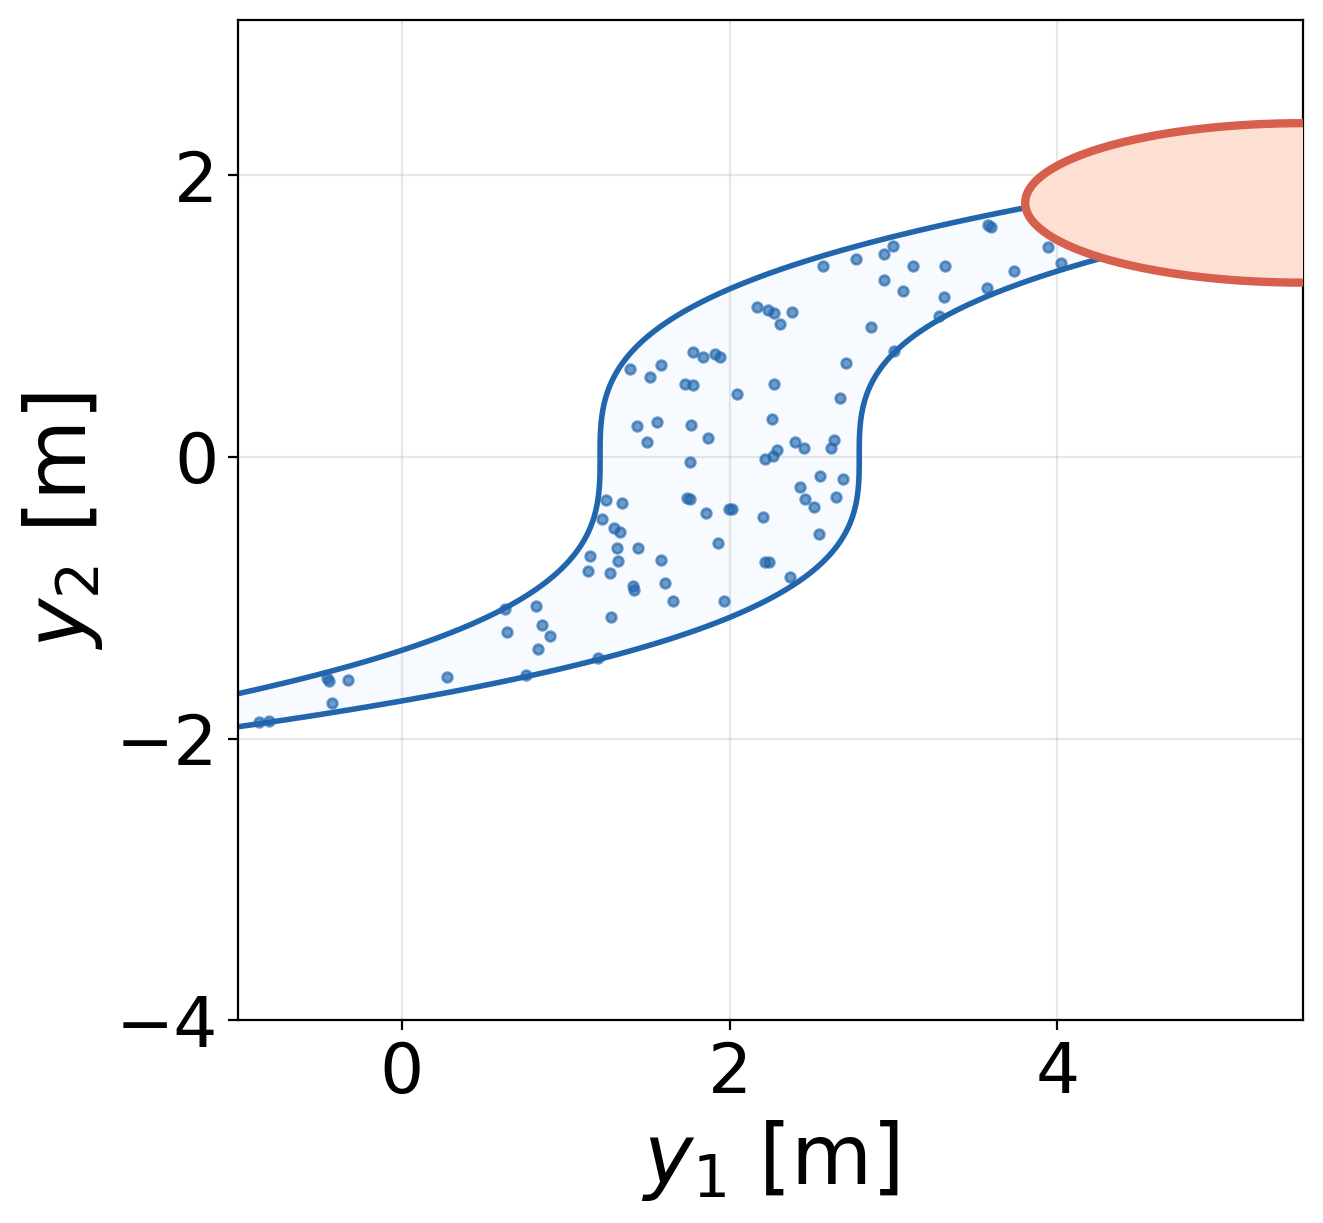

In [4]:
# ── Visualise RA-MPC feasible / infeasible initial states ─────────────────────
y_feasible = np.array([y1_samp[mpc_feasible_idx], y2_samp[mpc_feasible_idx]])
if mpc_infeasible_idx.size == 0:
    print("No infeasible points found among candidates!")
    y_infeasible = np.array([[], []])
else:
    y_infeasible = np.array([y1_samp[mpc_infeasible_idx], y2_samp[mpc_infeasible_idx]])

n_grid = 400
Y1g, Y2g = np.meshgrid(np.linspace(-1, 5.5, n_grid), np.linspace(-4, 3.1, n_grid))
Z_psi = psi_y_func(Y1g, Y2g)
Z_phi = phi_y_func(Y1g, Y2g)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

ax.contourf(
    Y1g, Y2g, Z_psi, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(Y1g, Y2g, Z_psi, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
ax.contourf(
    Y1g, Y2g, Z_phi, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1g, Y2g, Z_phi, levels=[0], colors=["#d6604d"], linewidths=3, zorder=4)

ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=12,
    color="#d73027",
    alpha=0.65,
    marker="x",
    linewidths=0.9,
    label=f"RA-MPC infeasible: {len(mpc_infeasible_idx)}",
    zorder=9,
)
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=12,
    color="#2166ac",
    alpha=0.65,
    marker="o",
    label=f"RA-MPC feasible: {len(mpc_feasible_idx)}",
    zorder=10,
)

fs = 30
ax.set_xlabel("$y_1$ [m]", fontsize=fs)
ax.set_ylabel("$y_2$ [m]", fontsize=fs)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
ax.grid(True, alpha=0.3)
plt.show()

In [5]:
# ── Receding-horizon RA-MPC simulation ────────────────────────────────────────
from scipy.integrate import solve_ivp
import time

T_max = 10.0
phi_tol = 0.05


def simulate_ra_mpc_traj(x0):
    """
    Simulate one trajectory under receding-horizon RA-MPC.

    Uses solve_mpc_fast (pre-compiled parametric NLP) — avoids repeated
    symbolic graph construction, typically 3-5× faster than solve_mpc.
    """
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0
    U_prev = None

    while t < T_max - 1e-9:
        if float(phi_x_np(x)) <= 0:
            break  # target reached

        ok, U_opt = solve_mpc_fast(x, U_warm=U_prev)  # ← pre-compiled NLP
        if not ok:
            break  # MPC infeasible

        u0 = np.array(U_opt[:, 0]).flatten()
        U_prev = U_opt

        def rhs(_, x_):
            return acrobot_rhs_np(_, x_, u0)

        sol = solve_ivp(
            rhs,
            [t, t + dt_mpc],
            x,
            method="DOP853",
            rtol=1e-8,
            atol=1e-10,
            max_step=dt_mpc / 10,
        )
        if not np.all(np.isfinite(sol.y)):
            break

        x = sol.y[:, -1]
        t += dt_mpc
        xs.append(x.copy())
        ts.append(t)

    ts = np.array(ts)
    xs = np.array(xs)
    q1, q2 = xs[:, 0], xs[:, 1]
    ys = np.column_stack(
        [l1 * np.cos(q1) + l2 * np.cos(q1 + q2), l1 * np.sin(q1) + l2 * np.sin(q1 + q2)]
    )
    return ts, xs, ys


# Simulate a batch from the first feasible candidates
N_sim_try = min(10, len(mpc_feasible_idx))
x_sim = x_samples[:, mpc_feasible_idx[:N_sim_try]]

raw = []
for i in range(N_sim_try):
    t0 = time.perf_counter()
    print(f"  [{i+1:2d}/{N_sim_try}] ", end="", flush=True)
    res = simulate_ra_mpc_traj(x_sim[:, i])
    raw.append(res)
    tt, tx, _ = res
    phi_f = float(phi_x_np(tx[-1]))
    elapsed = time.perf_counter() - t0
    print(
        f"T={tt[-1]:.2f}s  {'REACHED' if phi_f<=0 else f'phi={phi_f:.4f}'}  ({elapsed:.1f}s wall)"
    )

traj_t = [r[0] for r in raw]
traj_x = [r[1] for r in raw]
traj_y = [r[2] for r in raw]

  [ 1/10] 
******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

T=0.47s  REACHED  (2.3s wall)
  [ 2/10] T=0.46s  REACHED  (2.4s wall)
  [ 3/10] T=0.22s  REACHED  (0.9s wall)
  [ 4/10] T=0.26s  REACHED  (1.0s wall)
  [ 5/10] T=0.45s  REACHED  (2.4s wall)
  [ 6/10] T=0.48s  REACHED  (2.1s wall)
  [ 7/10] T=0.11s  REACHED  (0.4s wall)
  [ 8/10] T=0.48s  REACHED  (2.0s wall)
  [ 9/10] T=0.46s  REACHED  (2.5s wall)
  [10/10] T=0.43s  REACHED  (2.2s wall)


In [6]:
# plot the size of the simulated trajectories and each length
print(
    f"\nSimulated {len(traj_t)} trajectories (out of {N_sim_try} attempts, "
    f"capped for visualisation) -- lengths: {[len(t) for t in traj_t]}"
)


Simulated 10 trajectories (out of 10 attempts, capped for visualisation) -- lengths: [48, 47, 23, 27, 46, 49, 12, 49, 47, 44]


Kept 10/10 trajectories  (removed 0: hit T_max or did not reach target)


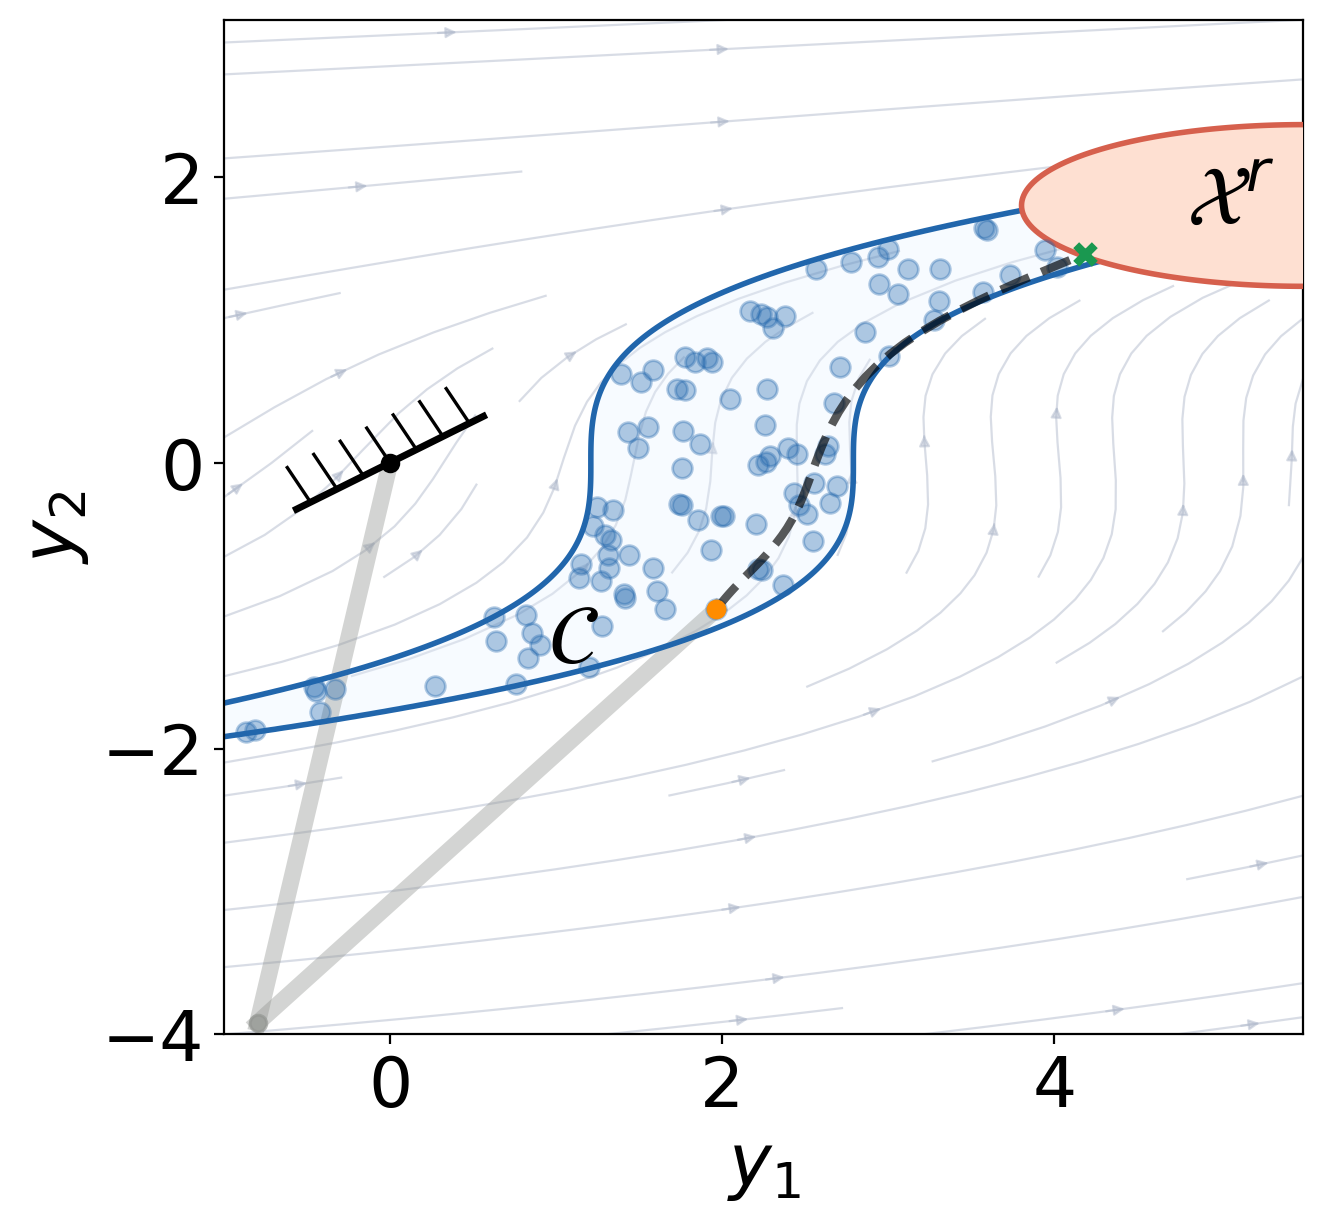

In [10]:
# ── Filter + visualise closed-loop trajectories ────────────────────────────────
T_min = 0.1

filtered = [
    (tt, tx, ty)
    for tt, tx, ty in zip(traj_t, traj_x, traj_y)
    if tt[-1] >= T_min and float(phi_x_np(tx[-1])) <= phi_tol
]
print(
    f"Kept {len(filtered)}/{len(traj_t)} trajectories  "
    f"(removed {len(traj_t)-len(filtered)}: hit T_max or did not reach target)"
)

# only plot 1 trajectory for visual clarity
filtered = filtered[0:1]

traj_t_plot, traj_x_plot, traj_y_plot = zip(*filtered) if filtered else ([], [], [])

# ── Grid for set contours ─────────────────────────────────────────────────────
n_grid = 400
Y1g, Y2g = np.meshgrid(np.linspace(-1, 5.5, n_grid), np.linspace(-4, 3.1, n_grid))
Z_psi = psi_y_func(Y1g, Y2g)
Z_phi = phi_y_func(Y1g, Y2g)

# ── k1 vector field ───────────────────────────────────────────────────────────
vf_y1 = np.linspace(-1, 5.5, 22)
vf_y2 = np.linspace(-4, 3.1, 22)
VF_Y1, VF_Y2 = np.meshgrid(vf_y1, vf_y2)
k1_vals = np.array(k1_func(VF_Y1, VF_Y2)).squeeze()  # (2, n, n)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

# k1 vector field
ax.streamplot(
    vf_y1,
    vf_y2,
    k1_vals[0],
    k1_vals[1],
    density=0.6,
    color=BetterColor.gray0(0.5),
    linewidth=0.8,
    arrowsize=0.8,
    zorder=0,
)

# Safe region
ax.contourf(
    Y1g, Y2g, Z_psi, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(Y1g, Y2g, Z_psi, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
# Target region
ax.contourf(
    Y1g, Y2g, Z_phi, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1g, Y2g, Z_phi, levels=[0], colors=["#d6604d"], linewidths=2, zorder=4)

# Feasible / infeasible scatter
ax.scatter(
    y_infeasible[0],
    y_infeasible[1],
    s=50,
    color="#d73027",
    alpha=0.85,
    marker="x",
    linewidths=3,
    label=f"RA-MPC infeasible: {len(mpc_infeasible_idx)}",
    zorder=6,
)
ax.scatter(
    y_feasible[0],
    y_feasible[1],
    s=50,
    color="#2166ac",
    alpha=0.35,
    marker="o",
    label=f"RA-MPC feasible: {len(mpc_feasible_idx)}",
    zorder=7,
)

# Closed-loop trajectories
for ty, tx in zip(traj_y_plot, traj_x_plot):
    ax.plot(
        ty[:, 0], ty[:, 1], color="black", lw=3, alpha=0.65, zorder=10, linestyle="--"
    )
    ax.scatter(
        ty[0, 0],
        ty[0, 1],
        s=45,
        c=[BetterColor.orange3()],
        marker="o",
        linewidths=0.4,
        zorder=20,
    )
    ax.scatter(
        ty[-1, 0],
        ty[-1, 1],
        s=45,
        c=[BetterColor.green0()],
        marker="x",
        linewidths=3.0,
        zorder=20,
    )
    # Initial arm configuration
    q1i, q2i = tx[0, 0], tx[0, 1]
    jx = l1 * np.cos(q1i)
    jy = l1 * np.sin(q1i)
    ex = jx + l2 * np.cos(q1i + q2i)
    ey = jy + l2 * np.sin(q1i + q2i)
    ax.plot(
        [0, jx], [0, jy], "o-", alpha=0.4, lw=6, color=BetterColor.gray2(), zorder=1
    )
    ax.plot(
        [jx, ex], [jy, ey], "o-", alpha=0.4, lw=6, color=BetterColor.gray2(), zorder=1
    )

# ── Angled wall (30°) supporting manipulator base ─────────────────────────────
wall_hw = 0.65
tick_len = 0.28
n_ticks = 7
θ = np.radians(30)
wd = np.array([np.cos(θ), np.sin(θ)])
wp = np.array([-np.sin(θ), np.cos(θ)])
p0, p1 = -wall_hw * wd, wall_hw * wd
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "k-", lw=2.5, zorder=50)
for s in np.linspace(-wall_hw * 0.85, wall_hw * 0.85, n_ticks):
    base = s * wd
    tip = base + tick_len * wp
    ax.plot([base[0], tip[0]], [base[1], tip[1]], "k-", lw=1.2, zorder=50)
ax.plot(0, 0, "ko", markersize=6, zorder=51)

fs = 30
ax.text(0.95, -1.4, r"$\mathcal{C}$", zorder=100, fontsize=fs)
ax.text(4.8, 1.67, r"$\mathcal{X}^r$", zorder=1000, fontsize=fs)
ax.set_xlabel("$y_1$", fontsize=fs - 4)
ax.set_ylabel("$y_2$", fontsize=fs - 4)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
ax.set_xlim(-1, 5.5)
ax.set_ylim(-4, 3.1)
plt.show()

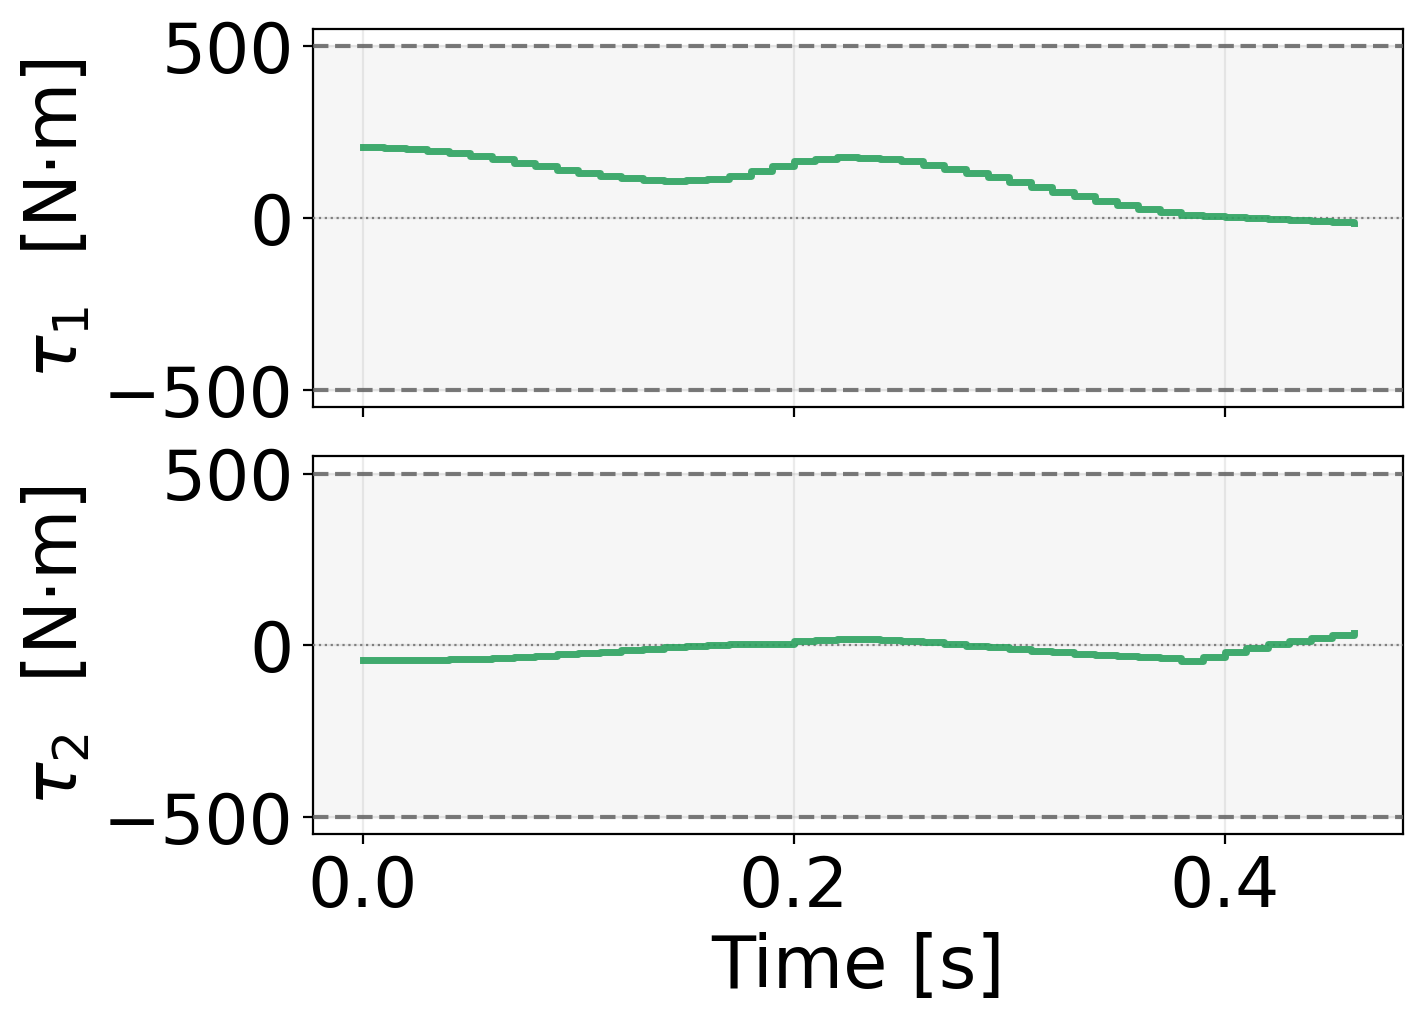

In [11]:
# ── Control inputs (torques) along filtered trajectories ─────────────────────
col_bound = "#636363"

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    2, 1, figsize=(700 * px_fig, 500 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

for ax in axes:
    ax.axhspan(-u_max, u_max, color="#f0f0f0", alpha=0.6, zorder=0)
    ax.axhline(
        u_max,
        color=col_bound,
        lw=1.5,
        ls="--",
        alpha=0.85,
        zorder=5,
        label=f"bound ±{u_max:.0f} N·m",
    )
    ax.axhline(-u_max, color=col_bound, lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(0, color="gray", lw=0.8, ls=":", zorder=4)

# RA-MPC applies piecewise-constant torques over each dt_mpc interval.
# Recover torques via the acrobot inverse dynamics:
#   tau = M(q)*qddot + C(q,qdot)*qdot + G(q)
# Approximated here from finite differences on qdot.
for tt, tx in zip(traj_t_plot, traj_x_plot):
    if len(tt) < 2:
        continue
    dt_arr = np.diff(tt)
    # Finite-diff acceleration estimate (reasonable since dt_mpc is constant)
    qddot_approx = np.diff(tx[:, 2:4], axis=0) / dt_arr[:, None]  # (N-1, 2)
    q = tx[:-1, :2]
    dq = tx[:-1, 2:]
    tau = np.zeros_like(qddot_approx)
    for i in range(len(dt_arr)):
        q1i, q2i, dq1i, dq2i = tx[i, 0], tx[i, 1], tx[i, 2], tx[i, 3]
        M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * np.cos(q2i))
        M12 = m2 * (lc2**2 + l1 * lc2 * np.cos(q2i)) + I2
        M_i = np.array([[M11, M12], [M12, m2 * lc2**2 + I2]])
        C_i = np.array(
            [
                [
                    -m2 * l1 * lc2 * np.sin(q2i) * dq2i,
                    -m2 * l1 * lc2 * np.sin(q2i) * (dq1i + dq2i),
                ],
                [m2 * l1 * lc2 * np.sin(q2i) * dq1i, 0.0],
            ]
        )
        G_i = np.array(
            [
                (m1 * g_grav * lc1 + m2 * g_grav * l1) * np.cos(q1i)
                + m2 * g_grav * lc2 * np.cos(q1i + q2i),
                m2 * g_grav * lc2 * np.cos(q1i + q2i),
            ]
        )
        tau[i] = M_i @ qddot_approx[i] + C_i @ np.array([dq1i, dq2i]) + G_i

    axes[0].step(
        tt[:-1],
        tau[:, 0],
        lw=2.5,
        alpha=0.9,
        color="#2ca25f",
        where="post",
        zorder=10,
        label="RA-MPC",
    )
    axes[1].step(
        tt[:-1],
        tau[:, 1],
        lw=2.5,
        alpha=0.9,
        color="#2ca25f",
        where="post",
        zorder=10,
        label="RA-MPC",
    )

fs = 30
for ax, lbl in zip(axes, [r"$\tau_1$  [N·m]", r"$\tau_2$  [N·m]"]):
    ax.set_ylabel(lbl, fontsize=fs - 4)
    ax.xaxis.set_tick_params(labelsize=25)
    ax.yaxis.set_tick_params(labelsize=25)
    ax.grid(True, alpha=0.25)
axes[1].set_xlabel("Time [s]", fontsize=fs - 4)

handles, labels_ = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
# axes[0].legend(by_label.values(), by_label.keys(), fontsize=16, loc="upper right")
plt.show()

In [12]:
# ── Export filtered trajectory control inputs for cross-method comparison ──────
# Torques recovered via acrobot inverse dynamics (same formula as cell above).
# Saved to traj_controls_ra_mpc_acrobot.npz, loaded by the unconstrained
# notebook to produce the combined control-input comparison figure.

if len(traj_t_plot) > 0:
    u1_list, u2_list = [], []
    for tt, tx in zip(traj_t_plot, traj_x_plot):
        if len(tt) < 2:
            continue
        dt_arr = np.diff(tt)
        qddot_approx = np.diff(tx[:, 2:4], axis=0) / dt_arr[:, None]  # (N-1, 2)
        tau = np.zeros_like(qddot_approx)
        for i in range(len(dt_arr)):
            q1i, q2i, dq1i, dq2i = tx[i, 0], tx[i, 1], tx[i, 2], tx[i, 3]
            M11 = (
                I1
                + I2
                + m1 * lc1**2
                + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * np.cos(q2i))
            )
            M12 = m2 * (lc2**2 + l1 * lc2 * np.cos(q2i)) + I2
            M_i = np.array([[M11, M12], [M12, m2 * lc2**2 + I2]])
            C_i = np.array(
                [
                    [
                        -m2 * l1 * lc2 * np.sin(q2i) * dq2i,
                        -m2 * l1 * lc2 * np.sin(q2i) * (dq1i + dq2i),
                    ],
                    [m2 * l1 * lc2 * np.sin(q2i) * dq1i, 0.0],
                ]
            )
            G_i = np.array(
                [
                    (m1 * g_grav * lc1 + m2 * g_grav * l1) * np.cos(q1i)
                    + m2 * g_grav * lc2 * np.cos(q1i + q2i),
                    m2 * g_grav * lc2 * np.cos(q1i + q2i),
                ]
            )
            tau[i] = M_i @ qddot_approx[i] + C_i @ np.array([dq1i, dq2i]) + G_i
        u1_list.append(tau[:, 0])
        u2_list.append(tau[:, 1])

    np.savez(
        "traj_controls_ra_mpc_acrobot.npz",
        traj_t=np.array(traj_t_plot, dtype=object),
        traj_x=np.array(traj_x_plot, dtype=object),
        traj_y=np.array(traj_y_plot, dtype=object),
        u1_traj=np.array(u1_list, dtype=object),
        u2_traj=np.array(u2_list, dtype=object),
        dt_mpc=np.array([dt_mpc]),
        u_max=np.array([u_max]),
    )
    print(
        f"Saved {len(traj_t_plot)} trajectory/ies to traj_controls_ra_mpc_acrobot.npz"
    )
    for i, (tt, u1, u2) in enumerate(zip(traj_t_plot, u1_list, u2_list)):
        print(
            f"  traj {i+1}: {len(tt)} states,  {len(u1)} control steps, "
            f"τ1 ∈ [{u1.min():.1f}, {u1.max():.1f}],  τ2 ∈ [{u2.min():.1f}, {u2.max():.1f}] N·m"
        )
else:
    print("No filtered trajectories to export.")

Saved 1 trajectory/ies to traj_controls_ra_mpc_acrobot.npz
  traj 1: 48 states,  47 control steps, τ1 ∈ [-15.0, 207.6],  τ2 ∈ [-44.0, 35.3] N·m
